## Importing Libraries and dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv(
    filepath_or_buffer="/kaggle/input/bestsellers-unveiled-global-top-selling-books/"
                        "best_selling_books_2.csv"
)
df.head(20)

,Rank,Title,Author,Volume Sales,Publisher,Genre
0,1,"Da Vinci Code,The","Brown, Dan","5,094,805",Transworld,"Crime, Thriller & Adventure"
1,2,Harry Potter and the Deathly Hallows,"Rowling, J.K.","4,475,152",Bloomsbury,Children's Fiction
2,3,Harry Potter and the Philosopher's Stone,"Rowling, J.K.","4,200,654",Bloomsbury,Children's Fiction
3,4,Harry Potter and the Order of the Phoenix,"Rowling, J.K.","4,179,479",Bloomsbury,Children's Fiction
4,5,Fifty Shades of Grey,"James, E. L.","3,758,936",Random House,Romance & Sagas
5,6,Harry Potter and the Goblet of Fire,"Rowling, J.K.","3,583,215",Bloomsbury,Children's Fiction
6,7,Harry Potter and the Chamber of Secrets,"Rowling, J.K.","3,484,047",Bloomsbury,Children's Fiction
7,8,Harry Potter and the Prisoner of Azkaban,"Rowling, J.K.","3,377,906",Bloomsbury,Children's Fiction
8,9,Angels and Demons,"Brown, Dan","3,193,946",Transworld,"Crime, Thriller & Adventure"
9,10,Harry Potter and the Half-blood Prince:Childre...,"Rowling, J.K.","2,950,264",Bloomsbury,Children's Fiction


Checking for missing values

In [3]:
df.isnull().sum()

Rank            0
Title           0
Author          0
Volume Sales    0
Publisher       0
Genre           0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rank          100 non-null    int64 
 1   Title         100 non-null    object
 2   Author        100 non-null    object
 3   Volume Sales  100 non-null    object
 4   Publisher     100 non-null    object
 5   Genre         100 non-null    object
dtypes: int64(1), object(5)
memory usage: 4.8+ KB


As you can see, `Volume Sales` is given in `object` dtype. However, it must be integer. 

In [5]:
df["Volume Sales"] = (
    df["Volume Sales"].replace(",", "", regex=True).astype("int64")
)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rank          100 non-null    int64 
 1   Title         100 non-null    object
 2   Author        100 non-null    object
 3   Volume Sales  100 non-null    int64 
 4   Publisher     100 non-null    object
 5   Genre         100 non-null    object
dtypes: int64(2), object(4)
memory usage: 4.8+ KB


Now, it is time for Explanatory Data Analysis :)

## Sales Volume and Genre

In [6]:
volume_genre = df.loc[:, ["Volume Sales", "Genre"]]

### How many genres do we have?

In [7]:
volume_genre["Genre"].unique()

array(['Crime, Thriller & Adventure', "Children's Fiction",
       'Romance & Sagas', 'Young Adult Fiction',
       'General & Literary Fiction', 'Popular Science', 'Picture Books',
       'Food & Drink: General', 'Humour: Collections & General',
       'Autobiography: General', 'Biography: The Arts',
       'Science Fiction & Fantasy', 'Fitness & Diet',
       'Usage & Writing Guides',
       'Popular Culture & Media: General Interest',
       'Autobiography: The Arts', 'Current Affairs & Issues',
       'Travel Writing', 'National & Regional Cuisine',
       "Children's Annuals", 'Biography: General'], dtype=object)

In [8]:
num_of_genres = len(volume_genre["Genre"].unique())
print(f"We have {num_of_genres} different genres.")

We have 21 different genres.


### Genres and corresponding amount of sales

In [9]:
volume_genre_sorted = (
    volume_genre
    .groupby(by="Genre")
    .sum()
    .sort_values(by="Volume Sales", ascending=False)
    .reset_index()
)

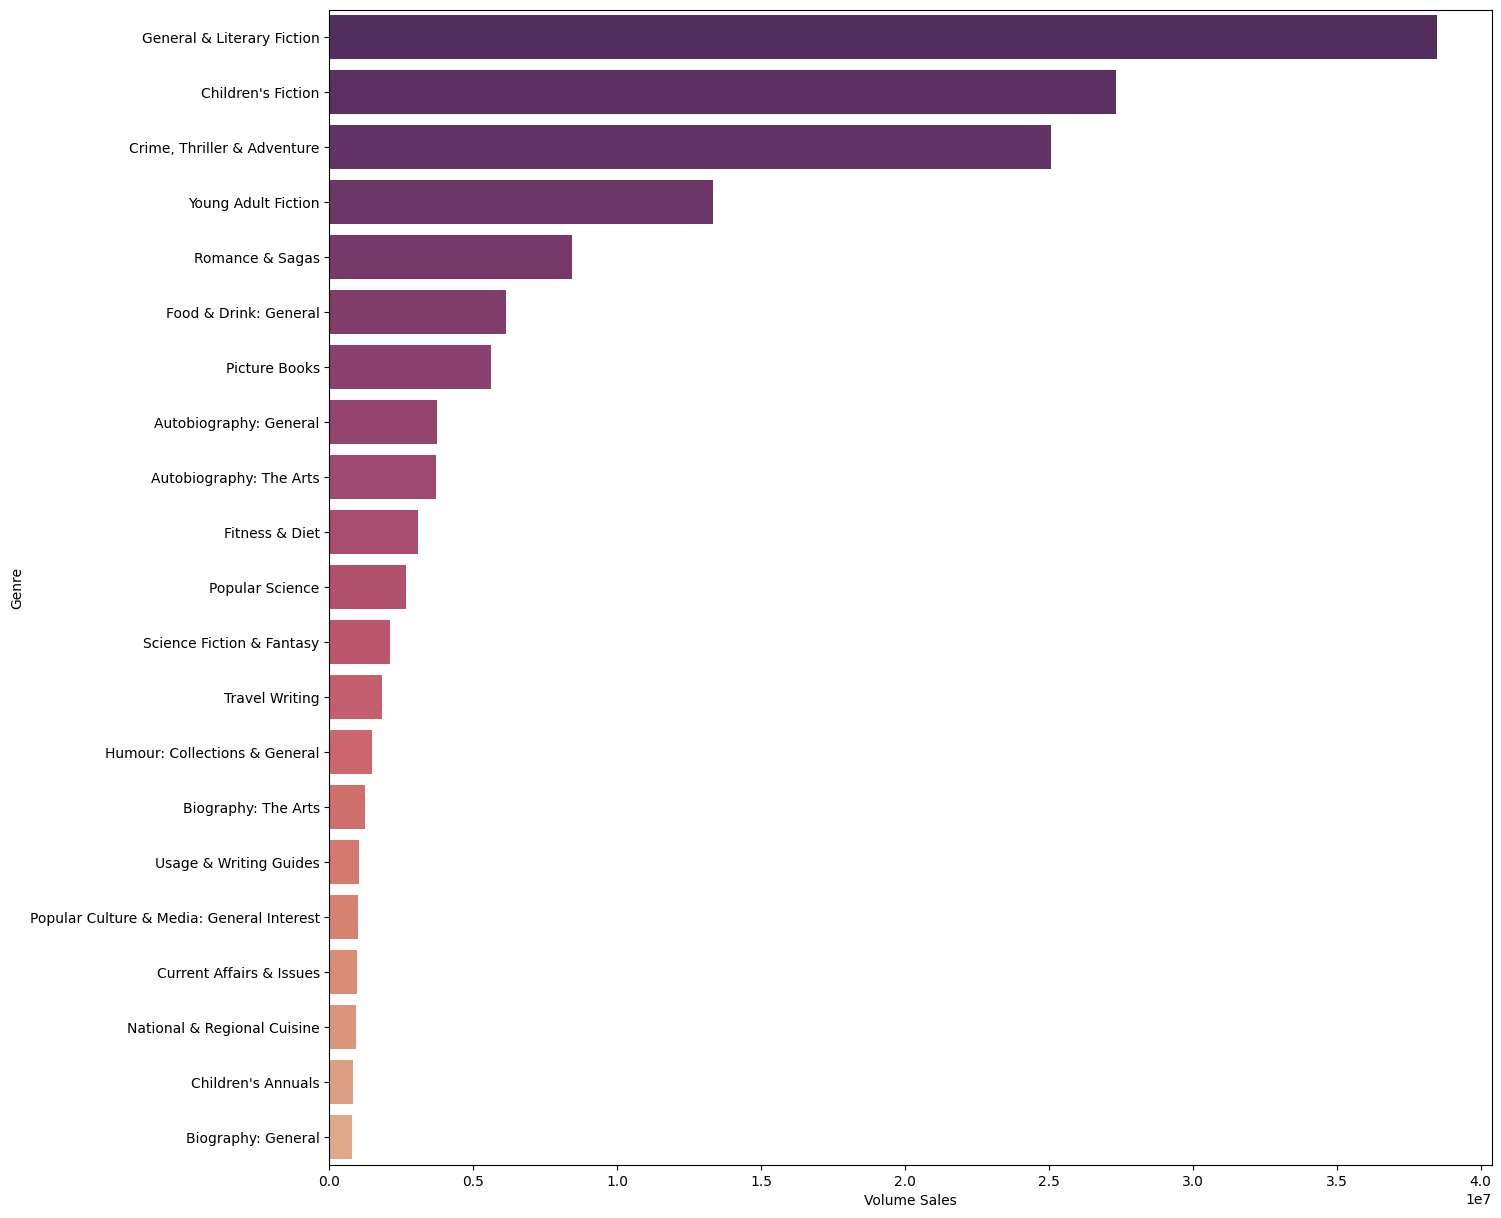

In [10]:
fig, ax = plt.subplots(figsize=(15, 15))

ax = sns.barplot(
    data=volume_genre_sorted,
    x="Volume Sales",
    y="Genre",
    hue="Volume Sales",
    palette="flare",
    dodge=False,
)

# Remove the legend
ax.legend().remove()

plt.show()

## ## Sales Volume and Publisher

In [11]:
volume_publisher = df.loc[:, ["Volume Sales", "Publisher"]]

### How many publishers do we have?

In [12]:
volume_publisher["Publisher"].unique()

array(['Transworld', 'Bloomsbury', 'Random House', 'Little, Brown Book',
       'Quercus', 'Pan Macmillan', 'Penguin', 'Hodder & Stoughton',
       'Canongate', 'HarperCollins', 'Orion', 'Scholastic Ltd.',
       'Headline', 'Profile Books Group',
       'Random House Childrens Books G', 'D.C. Thomson'], dtype=object)

In [13]:
num_of_publishers = len(volume_publisher["Publisher"].unique())
print(f"We have {num_of_publishers} different Publisher.")

We have 16 different Publisher.


### Publishers and corresponding amount of sales

In [14]:
volume_publisher_sorted = (
    volume_publisher
    .groupby(by="Publisher")
    .sum()
    .sort_values(by="Volume Sales", ascending=False)
    .reset_index()
)

volume_publisher_sorted

,Publisher,Volume Sales
0,Bloomsbury,31707856
1,Random House,27124816
2,Transworld,23481592
3,Penguin,15109759
4,"Little, Brown Book",10383181
5,Pan Macmillan,9085383
6,HarperCollins,7590622
7,Quercus,5603489
8,Orion,5091561
9,Scholastic Ltd.,4013164


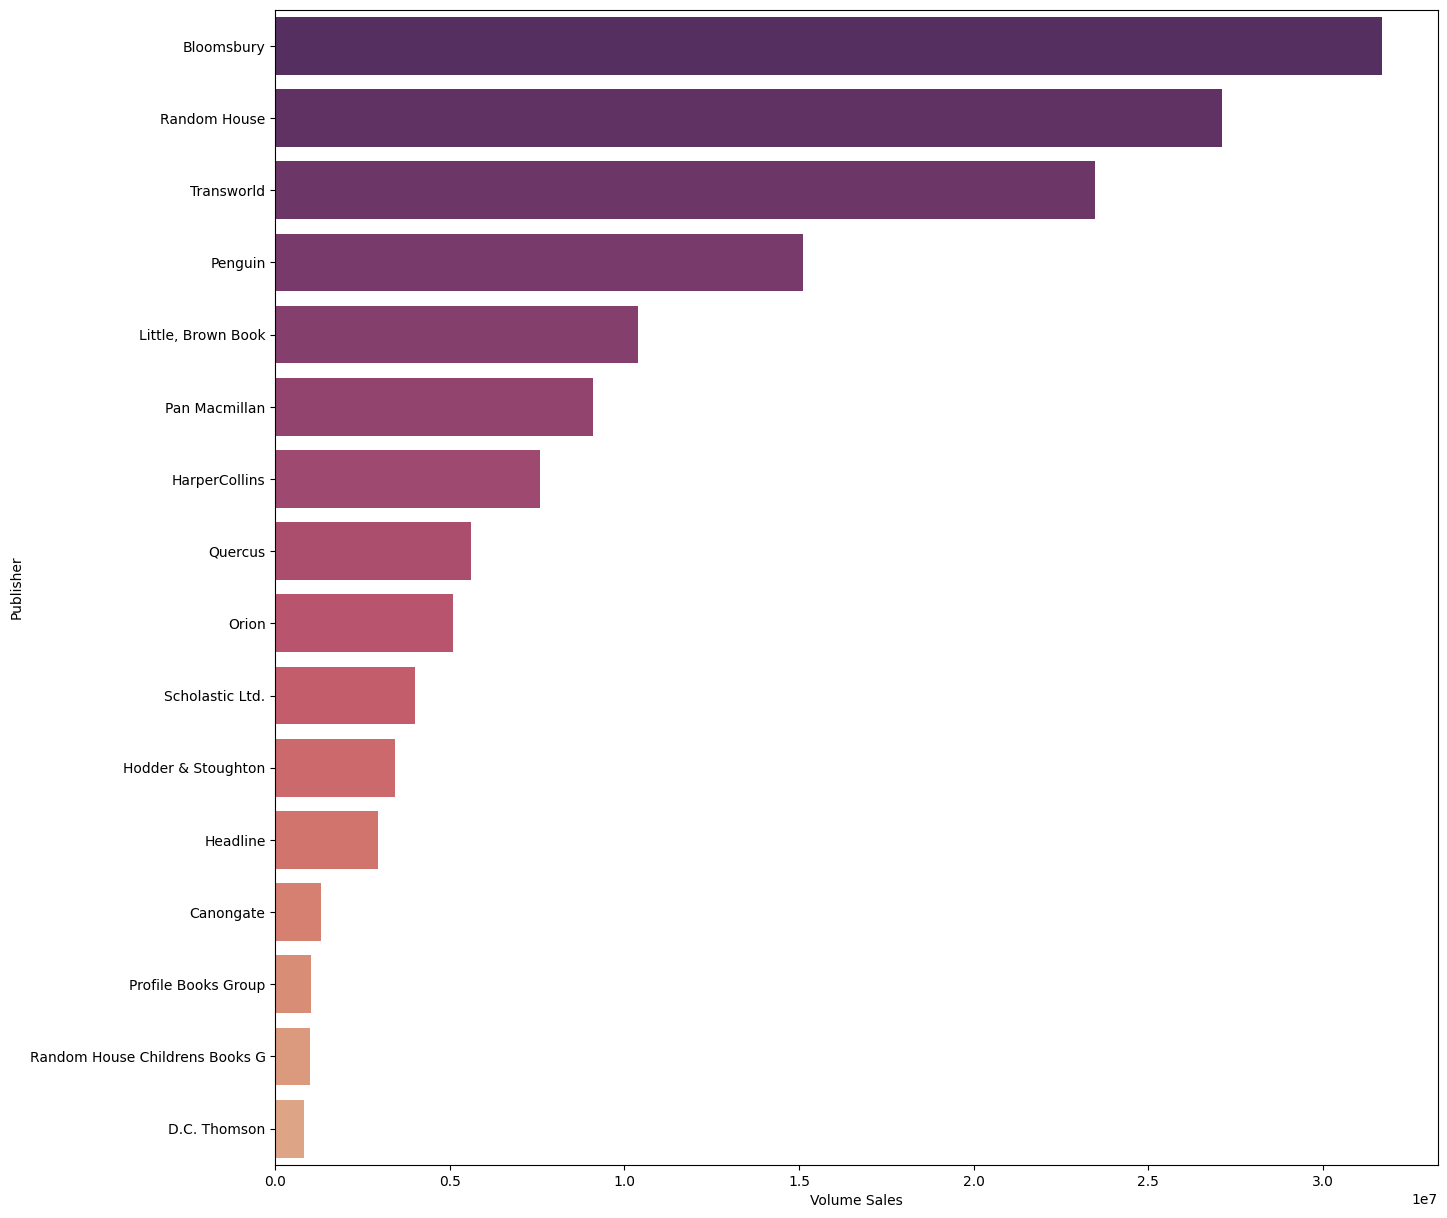

In [15]:
fig, ax = plt.subplots(figsize=(15, 15))

ax = sns.barplot(
    data=volume_publisher_sorted,
    x="Volume Sales",
    y="Publisher",
    hue="Volume Sales",
    palette="flare",
    dodge=False
)

ax.legend().remove()

plt.show()

## Book, Publisher and Volume

In [16]:
title_pub_vol = df.loc[:, ["Title", "Volume Sales", "Publisher"]]
title_pub_vol.head()

,Title,Volume Sales,Publisher
0,"Da Vinci Code,The",5094805,Transworld
1,Harry Potter and the Deathly Hallows,4475152,Bloomsbury
2,Harry Potter and the Philosopher's Stone,4200654,Bloomsbury
3,Harry Potter and the Order of the Phoenix,4179479,Bloomsbury
4,Fifty Shades of Grey,3758936,Random House


In [17]:
title_pub_vol_group = (
    title_pub_vol
    .groupby(by=["Publisher", "Title", "Volume Sales"])
    .sum()
)

title_pub_vol_group.head(15)

Empty DataFrame
Columns: []
Index: [(Bloomsbury, Harry Potter and the Chamber of Secrets, 3484047), (Bloomsbury, Harry Potter and the Deathly Hallows, 4475152), (Bloomsbury, Harry Potter and the Goblet of Fire, 3583215), (Bloomsbury, Harry Potter and the Half-blood Prince, 1153181), (Bloomsbury, Harry Potter and the Half-blood Prince:Children's Edition, 2950264), (Bloomsbury, Harry Potter and the Order of the Phoenix, 4179479), (Bloomsbury, Harry Potter and the Philosopher's Stone, 4200654), (Bloomsbury, Harry Potter and the Prisoner of Azkaban, 3377906), (Bloomsbury, Kite Runner,The, 1629119), (Bloomsbury, Tales of Beedle the Bard,The, 1090847), (Bloomsbury, Thousand Splendid Suns,A, 1583992), (Canongate, Life of Pi, 1310176), (D.C. Thomson, "Beano" Annual,The, 816585), (HarperCollins, Alchemist,The:A Fable About Following Your Dream, 956114), (HarperCollins, Angela's Ashes:A Memoir of a Childhood, 1204058)]

## Authors and theiry masterpieces

In [18]:
author_masterpiece = df.loc[:, ["Author", "Title", "Volume Sales"]]

In [19]:
author_masterpiece_group_sorted = (
    author_masterpiece
    .groupby(by=["Author", "Title", "Volume Sales"])
    .sum()
    .sort_values(by="Volume Sales", ascending=False)
)

author_masterpiece_group_sorted.head(15)

Empty DataFrame
Columns: []
Index: [(Brown, Dan, Da Vinci Code,The, 5094805), (Rowling, J.K., Harry Potter and the Deathly Hallows, 4475152), (Rowling, J.K., Harry Potter and the Philosopher's Stone, 4200654), (Rowling, J.K., Harry Potter and the Order of the Phoenix, 4179479), (James, E. L., Fifty Shades of Grey, 3758936), (Rowling, J.K., Harry Potter and the Goblet of Fire, 3583215), (Rowling, J.K., Harry Potter and the Chamber of Secrets, 3484047), (Rowling, J.K., Harry Potter and the Prisoner of Azkaban, 3377906), (Brown, Dan, Angels and Demons, 3193946), (Rowling, J.K., Harry Potter and the Half-blood Prince:Children's Edition, 2950264), (James, E. L., Fifty Shades Darker, 2479784), (Meyer, Stephenie, Twilight, 2315405), (Larsson, Stieg, Girl with the Dragon Tattoo,The:Millennium Trilogy, 2233570), (James, E. L., Fifty Shades Freed, 2193928), (Brown, Dan, Lost Symbol,The, 2183031)]

### Author and Sales Volume

In [20]:
author_volume = df.loc[:, ["Author", "Volume Sales"]]

In [21]:
author_volume_sorted = (
    author_volume
    .groupby(by="Author")
    .sum()
    .sort_values(by="Volume Sales", ascending=False)
    .reset_index()
)

author_volume_sorted.head()

,Author,Volume Sales
0,"Rowling, J.K.",28494745
1,"Brown, Dan",14462827
2,"James, E. L.",8432648
3,"Meyer, Stephenie",8308136
4,"Larsson, Stieg",5603489


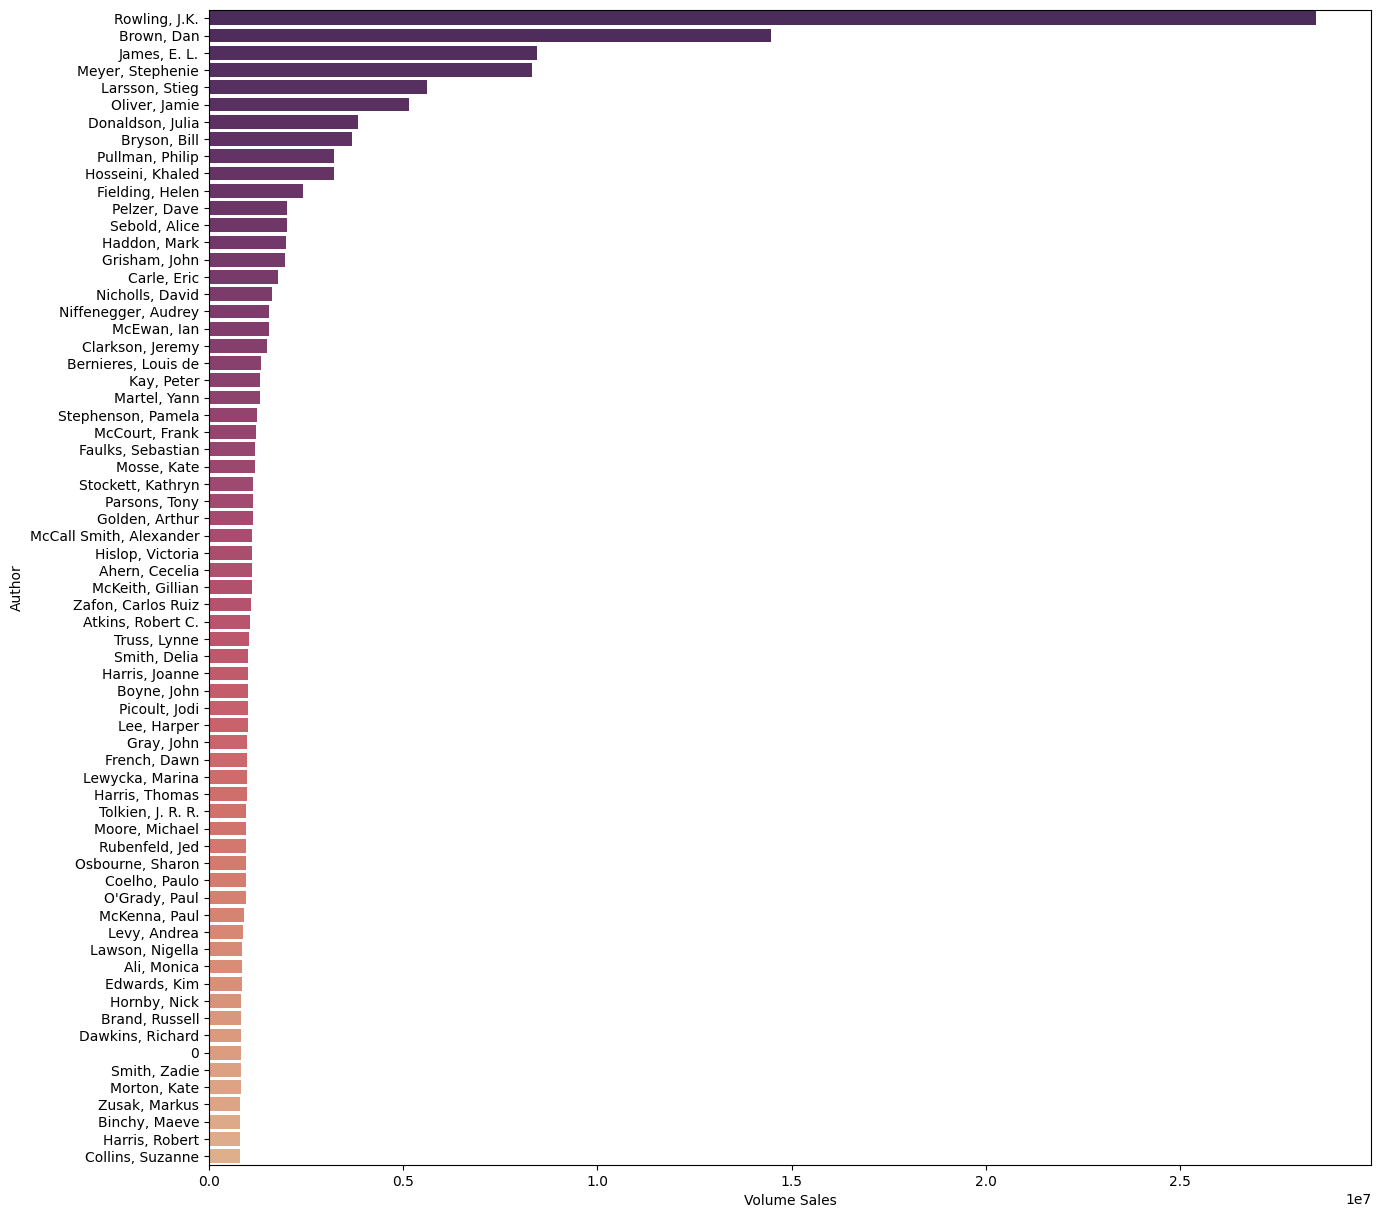

In [22]:
fig, ax = plt.subplots(figsize=(15, 15))

ax = sns.barplot(
    data=author_volume_sorted,
    x="Volume Sales",
    y="Author",
    hue="Volume Sales",
    palette="flare",
    dodge=False
)

ax.legend().remove()

plt.show()